## Funciones de Pérdida en Modelos de Lenguaje: De la Teoría Matemática a PyTorch

El éxito del entrenamiento de cualquier modelo útil depende directamente de elegir una función de pérdida (*loss function*) apropiada.

Para un entrenamiento estándar (*vanilla*), las implementaciones nativas que incluye PyTorch (`nn.CrossEntropyLoss`, `nn.NLLLoss`) son más que suficientes[cite: 1]. Sin embargo, si el objetivo es implementar esquemas de aprendizaje personalizados, penalizaciones específicas o regularizaciones no convencionales, es indispensable comprender la matemática que hay detrás para poder diseñar funciones de pérdida propias.

---

### 1. La Naturaleza de los Datos: ¿Por Qué son Categóricos?

En la tarea de predicción del siguiente token (*Next-Token Prediction*), el modelo trabaja con números enteros que representan índices dentro de un vocabulario fijo[cite: 1].

Aunque se manejen como enteros ($0, 1, 2, \dots, V-1$), representan **variables categóricas, discretas y mutuamente excluyentes**:
* No existe una relación de orden ni de magnitud: no podemos sumar el token con índice $10$ y el token con índice $20$ para esperar obtener el significado del token $30$.
* Cada token es una clase independiente dentro del vocabulario (por ejemplo, en GPT-2 hay $V \approx 50{,}000$ clases posibles)[cite: 1]. En cada posición de la secuencia, solo una palabra puede ser la correcta.

---

### 2. Entropía Cruzada Categórica (*Categorical Cross-Entropy*)

Para evaluar el error en problemas de clasificación multiclase, la formulación teórica de la entropía cruzada para un ejemplo individual se define como:

$$\mathcal{L} = - \sum_{c=1}^{C} y_c \cdot \log(\hat{y}_c)$$

Donde:
* $C$ es la cantidad total de categorías o fichas del vocabulario (en GPT, $C \approx 50{,}257$)[cite: 1].
* $y_c$ es la etiqueta real codificada en formato *one-hot*.
* $\hat{y}_c$ es la probabilidad asignada por el modelo a la categoría $c$ (la salida tras aplicar *Softmax*).

#### La simplificación por exclusión mutua:
Como las clases son **mutuamente excluyentes**, el vector de etiquetas reales $y$ contiene ceros en todas las posiciones excepto en el token objetivo real $k$:

$$y_c =
\begin{cases}
1 & \text{si } c = k \text{ (el token real objetivo)} \\
0 & \text{en cualquier otro caso } (c \neq k)
\end{cases}$$

Al multiplicar por cero todas las opciones incorrectas, la sumatoria completa de $50{,}000$ términos colapsa a un único valor:

$$\mathcal{L} = - \left( 0 + 0 + \dots + 1 \cdot \log(\hat{y}_k) + \dots + 0 \right)$$

$$\mathcal{L} = -\log(\hat{y}_k)$$

El costo total de la predicción se reduce simplemente al **negativo del logaritmo natural de la probabilidad asignada al token correcto**.
* Si el modelo asigna una probabilidad cercana a $1.0$ al token correcto, $-\log(1.0) = 0$ (pérdida casi nula).
* Si el modelo asigna una probabilidad cercana a $0.0$, el error tiende a infinito.

---

### 3. La Relación en PyTorch: `CrossEntropyLoss = LogSoftmax + NLLLoss`

En la práctica computacional con PyTorch se distinguen dos componentes esenciales[cite: 1]:

$$\text{CrossEntropyLoss} = \text{LogSoftmax} + \text{NLLLoss}$$

* **`Softmax`:** Convierte logits arbitrarios en probabilidades válidas:
  $$\hat{y}_c = \frac{e^{z_c}}{\sum_{j} e^{z_j}}$$
* **`NLLLoss` (*Negative Log-Likelihood Loss*):** Toma **log-probabilidades** y selecciona directamente el valor correspondiente al índice objetivo $k$ aplicando el signo negativo[cite: 1]:
  $$\text{NLLLoss}(\log(\hat{y}), k) = -\log(\hat{y}_k)$$

Por razones de estabilidad numérica (evitar problemas de subdesbordamiento o *underflow* al calcular exponenciales de números muy negativos), en modelos que aplican `F.log_softmax` en su salida, la pérdida se calcula directamente con `nn.NLLLoss`[cite: 1].


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

# vector plots
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

## Inspeccionar NLLL Loss

In [ ]:
# tenemos una def function y una def init

In [ ]:
help(nn.NLLLoss)

Help on class NLLLoss in module torch.nn.modules.loss:

class NLLLoss(_WeightedLoss)
 |  NLLLoss(
 |      weight: torch.Tensor | None = None,
 |      size_average=None,
 |      ignore_index: int = -100,
 |      reduce=None,
 |      reduction: str = 'mean'
 |  ) -> None
 |
 |  The negative log likelihood loss. It is useful to train a classification
 |  problem with `C` classes.
 |
 |  If provided, the optional argument :attr:`weight` should be a 1D Tensor assigning
 |  weight to each of the classes. This is particularly useful when you have an
 |  unbalanced training set.
 |
 |  The `input` given through a forward call is expected to contain
 |  log-probabilities of each class. `input` has to be a Tensor of size either
 |  :math:`(minibatch, C)` or :math:`(minibatch, C, d_1, d_2, ..., d_K)`
 |  with :math:`K \geq 1` for the `K`-dimensional case. The latter is useful for
 |  higher dimension inputs, such as computing NLL loss per-pixel for 2D images.
 |
 |  Obtaining log-probabilities in

In [ ]:
# Forma general para una función de pérdida (en realidad una clase)
class myLoss_L1(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, yHat, y):

    # Pérdida L1
    l = torch.mean(torch.abs(yHat - y)) # la magnitud de la discrepancia entre el target y la prediccion

    # Error de correlación (solo como ejemplo de posibilidades)
    # l = 1 - torch.corrcoef(yHat, y)

    return l


class myLoss_L2(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, yHat, y):

    # Error cuadrático medio (MSE) # l1 mide la magnitud del error y l2 el cuadrado del error
    l = torch.mean((yHat - y)**2)
    return l

In [ ]:
# Crear instancias de las clases de pérdida
lossfun1 = myLoss_L1()
lossfun2 = myLoss_L2()

# Valores de prueba
predicted_value = torch.tensor(2.0)
target_value = 5

# Reporte / Imprimir resultados
print(f'Salida del modelo = {predicted_value}')
print(f'Valor objetivo = {target_value}\n')
print(f'Pérdida L1: {lossfun1(predicted_value, target_value)}')
print(f'Pérdida L2: {lossfun2(predicted_value, target_value)}')

Salida del modelo = 2.0
Valor objetivo = 5

Pérdida L1: 3.0
Pérdida L2: 9.0


L1 es lineal - L2 es suave y cuadratica

In [ ]:
# Inicializar valor del peso
w1 = torch.tensor([2.0], requires_grad=True)
w2 = torch.tensor([2.0], requires_grad=True)

# Valor objetivo
target = torch.tensor([3.0])

# Crear los optimizadores
learningrate = 0.05
optimizer1 = torch.optim.SGD([w1], lr=learningrate)
optimizer2 = torch.optim.SGD([w2], lr=learningrate)

# Número de iteraciones de entrenamiento
numIters = 50

# Inicializar matrices de resultados
all_losses = np.zeros((2, numIters))
all_weights = np.zeros((2, numIters + 1))
all_weights[:, 0] = w1.item()

# Bucle de entrenamiento
for i in range(numIters):

  ## Entrenar peso w1 (L1)
  optimizer1.zero_grad()
  loss1 = lossfun1(w1, target)
  loss1.backward()
  optimizer1.step()

  # Almacenar las pérdidas y el valor del peso actualizado
  all_losses[0, i] = loss1.item()
  all_weights[0, i + 1] = w1.item()

  ## Entrenar peso w2 (L2)
  optimizer2.zero_grad()
  loss2 = lossfun2(w2, target)
  loss2.backward()
  optimizer2.step()

  # Almacenar las pérdidas y el valor del peso actualizado
  all_losses[1, i] = loss2.item()
  all_weights[1, i + 1] = w2.item()

## Visualización

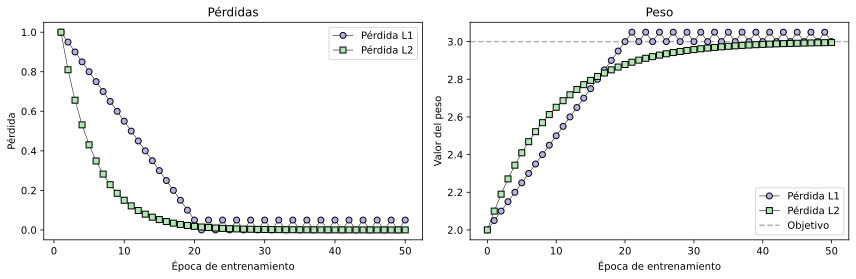

In [ ]:
_, axs = plt.subplots(1, 2, figsize=(12, 4))

# Graficar las pérdidas
axs[0].plot(
    range(1, numIters + 1),
    all_losses[0, :],
    'ko-',
    linewidth=0.5,
    markerfacecolor=[0.7, 0.7, 0.9],
    label='Pérdida L1',
)
axs[0].plot(
    range(1, numIters + 1),
    all_losses[1, :],
    'ks-',
    linewidth=0.5,
    markerfacecolor=[0.7, 0.9, 0.7],
    label='Pérdida L2',
)

# Graficar los pesos
axs[1].plot(
    range(0, numIters + 1),
    all_weights[0, :],
    'ko-',
    linewidth=0.5,
    markerfacecolor=[0.7, 0.7, 0.9],
    label='Pérdida L1',
)
axs[1].plot(
    range(0, numIters + 1),
    all_weights[1, :],
    'ks-',
    linewidth=0.5,
    markerfacecolor=[0.7, 0.9, 0.7],
    label='Pérdida L2',
)
axs[1].axhline(
    target.item(),
    linestyle='--',
    color=[0.7, 0.7, 0.7],
    zorder=-10,
    label='Objetivo',
)

# Agregar leyendas
axs[0].legend()
axs[1].legend()

# Dar estilo a los gráficos
axs[0].set(
    title='Pérdidas',
    ylabel='Pérdida',
    xlabel='Época de entrenamiento',
)
axs[1].set(
    title='Peso',
    ylabel='Valor del peso',
    xlabel='Época de entrenamiento',
)

plt.tight_layout()
plt.show()

### El objetivo del experimento

Partimos de un peso inicial $w = 2.0$ y queremos que llegue al objetivo $\text{target} = 3.0$ usando dos funciones de pérdida distintas con la misma tasa de aprendizaje ($\alpha = 0.05$):

* **Pérdida L1 (Error Absoluto):** $\mathcal{L}_1 = \vert{}w - \text{target}\vert{}$
* **Pérdida L2 (Error Cuadrático):** $\mathcal{L}_2 = (w - \text{target})^2$

---

### 1. ¿Quién llega más rápido al target?

**L1 toca primero la meta (alrededor de la época 20), pero L2 avanza con pasos más grandes al principio.**

* **En las primeras 15 épocas (L2 es más veloz):**
Al inicio, el error es grande ($\vert{}2 - 3\vert{} = 1$). La derivada de L2 es $2 \cdot (w - \text{target})$. Con un error considerable, el gradiente de L2 es alto, lo que produce pasos de actualización amplios. Por eso la curva verde sube con una pendiente pronunciada al comienzo.
* **Cerca de la época 20 (L1 alcanza primero el 3.0):**
La derivada de L1 es constante ($\pm 1$). Por tanto, L1 avanza exactamente a paso fijo en cada iteración:

$$\Delta w = \alpha \cdot 1 = 0.05$$



Para recorrer la distancia de $1.0$ (de $2.0$ a $3.0$), necesita exactamente:

$$\frac{1.0}{0.05} = 20 \text{ épocas}$$



En la época 20, L1 llega exactamente al $3.0$ (e incluso lo rebasa a $3.05$). En cambio, conforme L2 se acerca a la meta, su error se vuelve pequeño (fracciones decimales), su derivada se achica y sus pasos se vuelven microscópicos, frenándose antes de tocar exactamente el valor.

---

### 2. ¿Por qué ocurre el rebote (oscilación en L1)?

En el gráfico de la derecha se observa que, a partir de la época 20, los círculos morados de L1 empiezan a **rebotar indefinidamente entre 3.05 y 3.00**.

Esto se debe a la **magnitud constante del gradiente de L1**:

1. **Cuando $w < 3.0$:** La pendiente empuja a sumar $+0.05$. En la época 20 pasa de $3.00$ a $3.05$.
2. **Ahora $w = 3.05$ (se pasó):** Como $w > 3.0$, la derivada cambia abruptamente de signo a $+1$. El optimizador resta:

$$3.05 - 0.05 = 3.00$$


3. **En la siguiente época vuelve a dar un paso:** Como la derivada no se atenúa cerca de cero, no puede frenar suavemente. Queda atrapado en un ciclo infinito de **sobrepaso (overshoot) y corrección**, saltando siempre el tamaño de la tasa de aprendizaje ($0.05$).

---

### Comparación directa de comportamientos

| Característica | Pérdida L1 (Círculos morados) | Pérdida L2 (Cuadrados verdes) |
| --- | --- | --- |
| **Tamaño de paso** | Constante en todo momento ($0.05$) | Proporcional a la distancia al objetivo |
| **Al inicio (lejos de la meta)** | Paso moderado y constante | Pasos largos y agresivos |
| **Al final (cerca de la meta)** | No desacelera; se pasa de largo | Desacelera suavemente (asintótico) |
| **Convergencia final** | **Rebota** alrededor del óptimo | **Suave y estable**, se clava en $3.0$ sin oscilar |

Para evitar que L1 rebote de esa manera en escenarios reales, se suele usar un planificador que reduzca la tasa de aprendizaje con el tiempo (*learning rate decay*) o una función híbrida como **Smooth L1 Loss (Huber Loss)**, que se comporta como L1 lejos de la meta y como L2 cuando se aproxima a cero.

In [ ]:
# el valor de usar una funcion de error apropiada es muy importante - para tener la maxima flexibilidad y control del modelo a la hora del entrenamiento